<a href="https://colab.research.google.com/github/OMSCGR/Evaluacion-PMO/blob/main/estimaciones_pmo_rm_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evaluación de impacto de los PMO — Quito (abr-jun 2026)
**Robos de mayor connotación (RM)**

Este cuaderno reproduce, de principio a fin, las estimaciones del artículo sobre el efecto de los
Puestos de Mando Operativo (PMO) sobre los robos de mayor connotación en Quito.

El diseño es un **diferencias-en-diferencias (DiD) con efectos fijos de doble vía** (hexágono y mes)
sobre un panel balanceado hexágono-mes. Se estima:

1. El **efecto directo** de los PMO, con el resto de la ciudad como grupo de control (estimación principal).
2. La **prueba de desplazamiento / contagio**, comparando los hexágonos adyacentes con el resto de la ciudad.
3. El **efecto por zona**, con una estimación DiD independiente para cada uno de los cinco PMO.

> Para correrlo en Google Colab: `Entorno de ejecución → Ejecutar todo`, y sube el archivo cuando se te solicite.

## 1. Instalación de paquetes

Ejecutar una sola vez por sesión de Colab. `linearmodels` provee el estimador de panel con efectos fijos.

In [ ]:
!pip install linearmodels --quiet
print("Listo.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 2.1 MB/s eta 0:00:00
Listo.


## 2. Cargar la base

Sube el archivo `260707_hexagonos_Poligonos_PMO.xlsx` (hoja `hex_300_22_26_pmo`).
En Colab se abrirá un cuadro de diálogo para subirlo; en local, coloca el archivo junto al cuaderno.

In [ ]:
import pandas as pd
import numpy as np

NOMBRE_ARCHIVO = '260707_hexagonos_Poligonos_PMO.xlsx'
HOJA = 'hex_300_22_26_pmo'

try:
    from google.colab import files
    subidos = files.upload()
    NOMBRE_ARCHIVO = list(subidos.keys())[0]
except Exception:
    pass  # entorno local: usa NOMBRE_ARCHIVO tal cual

df = pd.read_excel(NOMBRE_ARCHIVO, sheet_name=HOJA)
print('Filas:', len(df))
print('Columnas:', list(df.columns))
df.head()

Saving 260707_hexagonos_Poligonos_PMO.xlsx to 260707_hexagonos_Poligonos_PMO.xlsx
Filas: 335520
Columnas: ['OBJECTID_1', 'OBJECTID', 'Input_FID', 'dpa_barrio', 'Nombre_Bar', 'Cod_Barrio', 'Parroquia', 'Cod_Parroq', 'Admin_Zona', 'AÑO', 'MES', 'CC', 'RM', 'HI', 'PMO', 'ADY', 'id', 'POLIGONO', 'INICIO']


,OBJECTID_1,OBJECTID,Input_FID,dpa_barrio,Nombre_Bar,Cod_Barrio,Parroquia,Cod_Parroq,Admin_Zona,AÑO,MES,CC,RM,HI,PMO,ADY,id,POLIGONO,INICIO
0,1,1,16321,170166001,CHIRIBOGA,EA_170166001,LLOA,170166,ELOY ALFARO,2025,Ene,0,0,0,0,0,0,NaN,NaT
1,2,2,16322,170166001,CHIRIBOGA,EA_170166001,LLOA,170166,ELOY ALFARO,2025,Ene,0,0,0,0,0,0,NaN,NaT
2,3,3,15724,170166001,CHIRIBOGA,EA_170166001,LLOA,170166,ELOY ALFARO,2025,Ene,0,0,0,0,0,0,NaN,NaT
3,4,4,15225,170166001,CHIRIBOGA,EA_170166001,LLOA,170166,ELOY ALFARO,2025,Ene,0,0,0,0,0,0,NaN,NaT
4,5,5,15425,170166001,CHIRIBOGA,EA_170166001,LLOA,170166,ELOY ALFARO,2025,Ene,0,0,0,0,0,0,NaN,NaT


## 3. Construir el panel mensual

- `periodo`: primer día del mes (año + mes), para ordenar la serie temporal.
- `mes_num`: índice consecutivo del mes (1, 2, 3, …), usado como dimensión temporal del panel.
- `grupo`: **PMO** (46 hexágonos intervenidos), **ADY** (64 adyacentes) o **RESTO** (resto de la ciudad).
- `post`: 1 desde abril de 2026 (inicio real de operación de los PMO), 0 antes.

> El campo `INICIO` de la base traía originalmente una fecha errónea (4 de enero de 2026);
> la operación real de los nueve PMO comenzó el **1 de abril de 2026**. Aquí se fija ese corte de forma explícita.

In [ ]:
meses_ord = {'Ene':1,'Feb':2,'Mar':3,'Abr':4,'May':5,'Jun':6,
             'Jul':7,'Ago':8,'Sep':9,'Oct':10,'Nov':11,'Dic':12}
df['mes_n'] = df['MES'].map(meses_ord)
assert df['mes_n'].notna().all(), 'Hay valores de MES no reconocidos'

df['periodo'] = pd.to_datetime(dict(year=df['AÑO'], month=df['mes_n'], day=1))

# índice temporal consecutivo
periodos = sorted(df['periodo'].unique())
idx_periodo = {p: i+1 for i, p in enumerate(periodos)}
df['mes_num'] = df['periodo'].map(idx_periodo)

# grupos a partir de las banderas PMO / ADY
def asignar_grupo(row):
    if row['PMO'] == 1:
        return 'PMO'
    if row['ADY'] == 1:
        return 'ADY'
    return 'RESTO'
df['grupo'] = df.apply(asignar_grupo, axis=1)

# corte post: abril 2026 en adelante
INICIO_PMO = pd.Timestamp('2026-04-01')
df['post'] = (df['periodo'] >= INICIO_PMO).astype(int)

print('Hexágonos únicos:', df['Input_FID'].nunique())
print('Meses:', df['mes_num'].nunique(), '(', periodos[0].date(), '→', periodos[-1].date(), ')')
print(df.groupby('grupo')['Input_FID'].nunique().rename('n_hexágonos'))

Hexágonos únicos: 18640
Meses: 18 ( 2025-01-01 → 2026-06-01 )
grupo
ADY         64
PMO         46
RESTO    18530
Name: n_hexágonos, dtype: int64


## 4. Transformación logarítmica

Se modela `ln(1 + casos)` en lugar de los conteos crudos. A esta escala territorial tan fina hay muchos
meses con cero incidentes; la transformación `ln(1+·)` los maneja adecuadamente y permite leer el
coeficiente, de forma aproximada, como un cambio porcentual.

In [ ]:
df['ln_RM'] = np.log1p(df['RM'])
df[['RM', 'ln_RM']].describe()

,RM,ln_RM
count,335520.000000,335520.000000
mean,0.063230,0.031989
std,0.448517,0.188871
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,0.000000,0.000000
max,18.000000,2.944439


## 5. Estadísticas descriptivas pre/post por grupo

Promedio de casos de RM por hexágono-mes, antes y después del inicio de los PMO.

In [ ]:
def resumen_prepost(var):
    filas = []
    for g in ['PMO', 'ADY', 'RESTO']:
        sub = df[df['grupo'] == g]
        pre = sub[sub['post'] == 0][var].mean()
        post = sub[sub['post'] == 1][var].mean()
        filas.append({'grupo': g, 'pre': round(pre, 3), 'post': round(post, 3),
                      'cambio_%': round((post/pre - 1) * 100, 1)})
    return pd.DataFrame(filas)

resumen_prepost('RM')

,grupo,pre,post,cambio_%
0,PMO,3.319,2.449,-26.2
1,ADY,1.744,1.516,-13.1
2,RESTO,0.052,0.041,-19.7


## 6. Diferencias-en-diferencias con efectos fijos de doble vía

$$\ln(1 + y_{it}) = \alpha_i + \gamma_t + \beta\,(\text{Tratado}_i \times \text{Post}_t) + \varepsilon_{it}$$

Cada dimensión de efectos fijos cumple una función de control:

- **Efectos fijos de hexágono** ($\alpha_i$): absorben todo lo constante en el tiempo de cada unidad
  (nivel estructural de criminalidad, densidad comercial y peatonal, configuración urbana). El estimador
  compara cada hexágono **consigo mismo** antes y después, de modo que no confunde el efecto del PMO
  con que las zonas intervenidas eran, por diseño, lugares de alta criminalidad previa.
- **Efectos fijos de mes** ($\gamma_t$): absorben todo shock común a la ciudad en un mes dado
  (estacionalidad, política del gobierno central, coyuntura). Así $\beta$ no captura la tendencia general
  a la baja de Quito, sino la **desviación adicional** de las zonas PMO respecto de esa tendencia.

Los errores estándar se **agrupan (cluster) por hexágono** para acomodar la autocorrelación serial.

La estimación principal es **PMO vs. RESTO**. Se reportan también PMO vs. ADY y ADY vs. RESTO.

In [ ]:
from linearmodels.panel import PanelOLS

def estimar_did(grupo_tratado, grupo_control, variable='ln_RM'):
    sub = df[df['grupo'].isin([grupo_tratado, grupo_control])].copy()
    sub['tratado'] = (sub['grupo'] == grupo_tratado).astype(int)
    sub['did'] = sub['tratado'] * sub['post']
    sub = sub.set_index(['Input_FID', 'mes_num'])
    mod = PanelOLS(sub[variable], sub[['did']], entity_effects=True, time_effects=True)
    res = mod.fit(cov_type='clustered', cluster_entity=True)
    coef = res.params['did']
    ci_l, ci_u = res.conf_int().loc['did']
    return {
        'comparación': f'{grupo_tratado} vs. {grupo_control}',
        'coef_ln': round(coef, 3),
        'IC95_inf': round(ci_l, 3),
        'IC95_sup': round(ci_u, 3),
        'p_valor': round(res.pvalues['did'], 4),
        'efecto_%': round((np.exp(coef) - 1) * 100, 1),
    }

tabla_did = pd.DataFrame([
    estimar_did('PMO', 'RESTO'),   # estimación principal
    estimar_did('PMO', 'ADY'),
    estimar_did('ADY', 'RESTO'),   # prueba de desplazamiento / contagio
])
tabla_did

,comparación,coef_ln,IC95_inf,IC95_sup,p_valor,efecto_%
0,PMO vs. RESTO,-0.187,-0.268,-0.105,0.0000,-17.0
1,PMO vs. ADY,-0.089,-0.195,0.017,0.0997,-8.5
2,ADY vs. RESTO,-0.098,-0.164,-0.031,0.0041,-9.3


## 7. Event-study (verificación de tendencias previas paralelas)

Se interactúa el indicador de tratamiento con dummies mensuales, tomando **marzo de 2026** —el mes
inmediatamente previo a la intervención— como categoría de referencia. Si el diseño es válido, ningún
mes **previo** a abril de 2026 debería mostrar una brecha significativa entre tratados y controles.

In [ ]:
def event_study(grupo_tratado, grupo_control, variable='ln_RM', ref_periodo='2026-03-01'):
    sub = df[df['grupo'].isin([grupo_tratado, grupo_control])].copy()
    sub['tratado'] = (sub['grupo'] == grupo_tratado).astype(int)
    ref = pd.Timestamp(ref_periodo)
    periodos_ord = sorted(sub['periodo'].unique())
    # dummies tratado × mes, excluyendo el mes de referencia
    for p in periodos_ord:
        if p == ref:
            continue
        etq = p.strftime('%Y_%m')
        sub[f'tm_{etq}'] = sub['tratado'] * (sub['periodo'] == p).astype(int)
    cols = [c for c in sub.columns if c.startswith('tm_')]
    s = sub.set_index(['Input_FID', 'mes_num'])
    mod = PanelOLS(s[variable], s[cols], entity_effects=True, time_effects=True)
    res = mod.fit(cov_type='clustered', cluster_entity=True)
    filas = []
    for c in cols:
        p = pd.Timestamp(c.replace('tm_', '').replace('_', '-') + '-01')
        ci_l, ci_u = res.conf_int().loc[c]
        filas.append({'periodo': p, 'coef': res.params[c], 'se': res.std_errors[c],
                      'IC_inf': ci_l, 'IC_sup': ci_u, 'p_valor': res.pvalues[c]})
    out = pd.DataFrame(filas).sort_values('periodo').reset_index(drop=True)
    out['post'] = (out['periodo'] >= pd.Timestamp('2026-04-01')).astype(int)
    return out

es_rm_resto = event_study('PMO', 'RESTO')
es_rm_ady_resto = event_study('ADY', 'RESTO')
es_rm_resto.round(3)

,periodo,coef,se,IC_inf,IC_sup,p_valor,post
0,2025-01-01,-0.050,0.087,-0.222,0.121,0.566,0
1,2025-02-01,-0.100,0.109,-0.314,0.115,0.363,0
2,2025-03-01,0.063,0.095,-0.123,0.248,0.507,0
3,2025-04-01,-0.101,0.090,-0.278,0.076,0.263,0
4,2025-05-01,0.117,0.095,-0.069,0.302,0.218,0
5,2025-06-01,-0.049,0.093,-0.231,0.134,0.601,0
6,2025-07-01,-0.098,0.117,-0.327,0.131,0.401,0
7,2025-08-01,-0.133,0.098,-0.325,0.058,0.173,0
8,2025-09-01,0.104,0.107,-0.107,0.315,0.334,0
9,2025-10-01,-0.008,0.095,-0.194,0.179,0.936,0


### Chequeo rápido: ¿cuántos meses previos ya eran significativos?

Idealmente, **cero** meses previos significativos (tendencias paralelas). Los meses post sí deberían serlo
si la intervención tuvo efecto.

In [ ]:
def resumen_significancia(es_df, etiqueta):
    pre = es_df[es_df['post'] == 0]
    post = es_df[es_df['post'] == 1]
    print(f'{etiqueta}:')
    print(f'  meses previos significativos (p<0.05): {(pre["p_valor"] < 0.05).sum()} de {len(pre)}')
    print(f'  meses post significativos (p<0.05):    {(post["p_valor"] < 0.05).sum()} de {len(post)}')

resumen_significancia(es_rm_resto, 'RM · PMO vs. RESTO')
resumen_significancia(es_rm_ady_resto, 'RM · ADY vs. RESTO (prueba de desplazamiento)')

RM · PMO vs. RESTO:
  meses previos significativos (p<0.05): 0 de 14
  meses post significativos (p<0.05):    2 de 3
RM · ADY vs. RESTO (prueba de desplazamiento):
  meses previos significativos (p<0.05): 0 de 14
  meses post significativos (p<0.05):    0 de 3


## 8. Figuras del event-study

Coeficiente mes a mes con intervalo de confianza al 95%. La línea roja marca el inicio de los PMO (abril 2026).

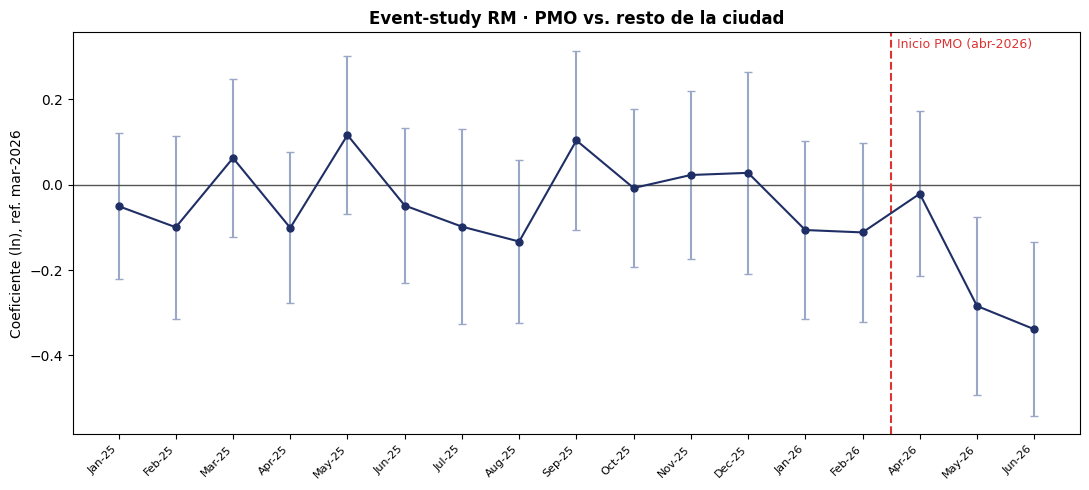

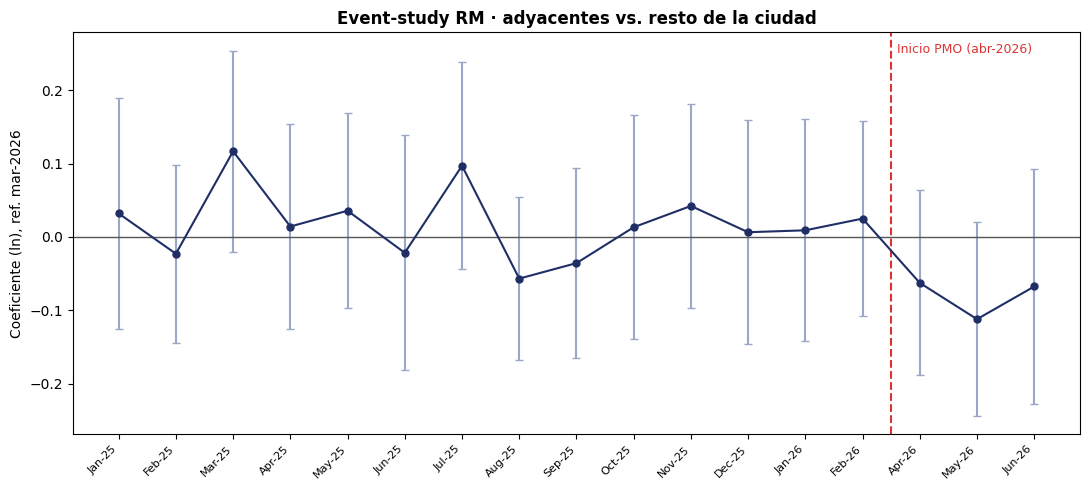

In [ ]:
import matplotlib.pyplot as plt

def graficar_event_study(es_df, titulo):
    fig, ax = plt.subplots(figsize=(11, 5))
    x = range(len(es_df))
    ax.errorbar(x, es_df['coef'],
                yerr=[es_df['coef'] - es_df['IC_inf'], es_df['IC_sup'] - es_df['coef']],
                fmt='o-', color='#1f2f66', ecolor='#9aa7c7', capsize=3, markersize=5)
    ax.axhline(0, color='#555', lw=1)
    # línea de inicio: primer mes post
    post_idx = es_df.index[es_df['post'] == 1]
    if len(post_idx):
        ax.axvline(post_idx[0] - 0.5, color='#d33', ls='--', lw=1.5)
        ax.text(post_idx[0] - 0.4, ax.get_ylim()[1]*0.9, 'Inicio PMO (abr-2026)', color='#d33', fontsize=9)
    ax.set_xticks(list(x))
    ax.set_xticklabels([p.strftime('%b-%y') for p in es_df['periodo']], rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Coeficiente (ln), ref. mar-2026')
    ax.set_title(titulo, fontsize=12, weight='bold')
    plt.tight_layout()
    return fig

graficar_event_study(es_rm_resto, 'Event-study RM · PMO vs. resto de la ciudad')
graficar_event_study(es_rm_ady_resto, 'Event-study RM · adyacentes vs. resto de la ciudad')
plt.show()

## 9. Efecto por zona: una estimación DiD separada para cada PMO

Para examinar si el efecto es transversal o descansa sobre unas pocas zonas, se estima un DiD
**independiente para cada PMO**, tomando como tratado únicamente los hexágonos de esa zona.

> **Precisión importante del grupo de control**: se compara cada zona contra el resto de la ciudad,
> pero se **excluyen del control tanto los hexágonos de los otros cuatro PMO como todos los adyacentes**.
> Así cada estimación enfrenta una sola zona intervenida contra la ciudad no expuesta, sin contaminación
> de otras intervenciones ni de sus anillos de posible desplazamiento.

In [ ]:
def did_por_zona(poligono, variable='ln_RM'):
    tratado = df[(df['grupo'] == 'PMO') & (df['POLIGONO'] == poligono)].copy()
    # control = RESTO puro (excluye otros PMO y todos los ADY)
    control = df[df['grupo'] == 'RESTO'].copy()
    d = pd.concat([tratado, control], ignore_index=True)
    d['tratado'] = (d['POLIGONO'] == poligono).astype(int)
    d['did'] = d['tratado'] * d['post']
    d = d.set_index(['Input_FID', 'mes_num'])
    mod = PanelOLS(d[variable], d[['did']], entity_effects=True, time_effects=True)
    res = mod.fit(cov_type='clustered', cluster_entity=True)
    coef = res.params['did']
    ci_l, ci_u = res.conf_int().loc['did']
    pre = tratado[tratado['post'] == 0]['RM'].mean()
    post = tratado[tratado['post'] == 1]['RM'].mean()
    return {
        'zona': poligono,
        'n_hex': tratado['Input_FID'].nunique(),
        'pre': round(pre, 2), 'post': round(post, 2),
        'coef_ln': round(coef, 3),
        'IC95_inf': round(ci_l, 3), 'IC95_sup': round(ci_u, 3),
        'p_valor': round(res.pvalues['did'], 4),
        'efecto_%': round((np.exp(coef) - 1) * 100, 1),
    }

poligonos = df[df['grupo'] == 'PMO']['POLIGONO'].unique()
tabla_zonas = pd.DataFrame([did_por_zona(p) for p in poligonos])
tabla_zonas = tabla_zonas.sort_values('coef_ln').reset_index(drop=True)
tabla_zonas

,zona,n_hex,pre,post,coef_ln,IC95_inf,IC95_sup,p_valor,efecto_%
0,PMO La Carolina (Hipercentro/República del Sal...,8,5.32,3.50,-0.380,-0.544,-0.216,0.0000,-31.6
1,Cuadrante Centro Histórico (Subcuadrante Merca...,13,3.14,2.33,-0.199,-0.387,-0.010,0.0385,-18.0
2,El Panecillo,3,0.96,0.67,-0.136,-0.335,0.063,0.1799,-12.7
3,Cuadrante La Mariscal (Centro de Innovación y ...,14,4.42,3.55,-0.123,-0.217,-0.028,0.0108,-11.6
4,Cumbayá centro,8,0.55,0.33,-0.103,-0.302,0.096,0.3101,-9.8


**Lectura.** El efecto diferencial es negativo en las cinco zonas (ninguna excepción de signo), lo que
confirma que la reducción agregada no depende de una sola zona. Las zonas con más hexágonos y mayor
criminalidad previa (La Carolina, Centro Histórico, La Mariscal) alcanzan significancia estadística; las
más pequeñas y de baja incidencia previa (El Panecillo, Cumbayá) mantienen el signo negativo pero no
cruzan el umbral de significancia, por falta de potencia antes que por ausencia de efecto.

## 10. Exportar resultados

Guarda las tablas principales como CSV. En Colab, aparecerán en el panel de archivos (ícono de carpeta)
y pueden descargarse desde ahí.

In [ ]:
tabla_did.to_csv('pmo_did_principal.csv', index=False)
es_rm_resto.to_csv('pmo_event_study_rm_resto.csv', index=False)
es_rm_ady_resto.to_csv('pmo_event_study_ady_resto.csv', index=False)
tabla_zonas.to_csv('pmo_did_por_zona.csv', index=False)
print('Archivos exportados:')
print('  pmo_did_principal.csv')
print('  pmo_event_study_rm_resto.csv')
print('  pmo_event_study_ady_resto.csv')
print('  pmo_did_por_zona.csv')

try:
    from google.colab import files
    for f in ['pmo_did_principal.csv', 'pmo_event_study_rm_resto.csv',
              'pmo_event_study_ady_resto.csv', 'pmo_did_por_zona.csv']:
        files.download(f)
except Exception:
    pass

Archivos exportados:
  pmo_did_principal.csv
  pmo_event_study_rm_resto.csv
  pmo_event_study_ady_resto.csv
  pmo_did_por_zona.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>